# <font color="brown">**Heritage Institute of Technology**
# <font color="brown">**Department of AEIE**
# <font color="brown">**MACHINE LEARNING TECHNIQUES LAB (AEI3262)**
# <font color="brown">**B. Tech AEIE,   6th Semester**
# <font color="Blue">**Experiment No. 7: Support Vector Machine Classifier </font>**  **[CO: AEI3262.3]**


# <font color="Blue">**Objective:**

- To apply SVM for classification with multiple kernel functions.
- To train SVM classifiers using linear, polynomial, and RBF kernels.
- To perform tuning of model parameters using grid search technique.
- To evaluate performance metrices and visualize decision boundaries in 2D space (if feasible).

# <font color="Blue"> **A: Learning Outcome:**
## After completion of this assignment you will be able to:

*  Apply SVM classifier models on a given data set.
*  Learn how to find optimal model parameters by grid search technique.
*  Compute the performance of the model.


# <font color="Blue">**B. Instructions:**
* You will be using Python 3.
* Avoid using for-loops and while-loops, unless you are explicitly told to do so.
* Do not modify the function name, variable names, comments in cells.
* Write your code where it is asked to write.
* After your coding, run the cell and see your results.

# <font color="Blue">**C. Useful PYTHON Commands**
Some useful PYTHON commands that may be required to perform this experiment are given below:
# <font color="magenta">*Requird Library:*
    numpy     pands    sklearn    matplotlib.pyplot

# <font color="magenta"> *Elementary Functions from numpy:*
    np.unique()        np.meshgrid()    np.arange()      

# <font color="magenta">*Functions from matplotlib.pyplot:*
    plt.figure()   plt.plot()     plt.scatter()  plt.title()
    plt.xlabel()   plt.ylabel()   plt.xticks()   plt.yticks()  
    plt.legend()   plt.grid()     plt.show()     plt.text()
    plt.bar()      plt.contourf()

# <font color="magenta"> *Elementary Functions from Seaborn:*
    sns.heatmap()

# <font color="magenta">*Modules and Methods of sklearn library:*
    sklearn.preprocessing.MinMaxScaler()
    sklearn.preprocessing.StandardScaler()
    scaler.transform()
    from sklearn.svm import SVC
    model.fit()
    model.predict()
    model.decision_function()
    model.support_vectors_
    sklearn.model_selection.train_test_split(), GridSearchCV()
    sklearn.metrics.confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
    sklearn.decomposition.PCA()
         

# *For detail information of the SVM classifiers of sklearn see the following links:*
https://scikit-learn.org/stable/modules/svm.html


# <font color="green">**1. Introduction: <font color="green">**

**Support Vector Machine (SVM)** is a supervised learning algorithm used for classification and regression.

## Basic Idea:
SVM finds an optimal hyperplane:

$\;\;\;\;\;\;\;\;\;\;\;\;\;\;\omega^{T}x+b=0$

that maximizes the margin between classes.

Objective function:
$\min_{w, b} \; \frac{1}{2} \|w\|^2$

$\text{Subject to: } \quad y_i \left( w^T x_i + b \right) \geq 1, \quad \forall i = 1,2,\dots,n$

## Kernel trick: $K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$

##Common Kernel Functions:
* Linear Kernel: $K(x_i, x_j) = x_i^T x_j$

* Polynomial Kernel:  $K(x_i, x_j) = \left( x_i^T x_j + c \right)^d$

* RBF Kernel: $K(x_i, x_j) = \exp\left( -\gamma \| x_i - x_j \|^2 \right)$

##<font color="blue"> **Problem-1:**</font> Implement SVM  classifier on real-world data set, e.g., **breast cancer**, **wine**, **digits**, etc., using Scikit-learn.

i) Load the dataset.

ii) Split the dataset into training and testing sets in the ratio of 70:30 and normalize within [0 1].

iii) Find the optimal parameters of the  classifier with linear, polynomial and RBF kernel using grid search technique and 5-fold cross validation (CV).

iv) Train the classifiers using optimal parameter sets on training data.

v) Evaluate the performances of the models on test set and evaluate (a) Accuracy (b) Precision (c) Recall and (d) F1-score; and visualize Confusion Matrix of the model.

# <font color="magenta"> **Step 1: Import Required Libraries**

In [ ]:
##Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine, load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# <font color="magenta"> **Step 2: Load Dataset and Split (train: test=70:30)**

In [ ]:
##Load any real world data set
wine = load_wine()
print(wine.keys)

<built-in method keys of Bunch object at 0x7bc803ad9a90>


In [ ]:
## Perform stratified train-test split (70% train, 30% test)
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, stratify=y, random_state= 42)


# <font color="magenta"> **Step 3: Scale the training and testing data**

In [ ]:
##Scale the data set using MinMaxScaler
Scaler = MinMaxScaler()

X_train = Scaler.fit_transform(X_train)
X_test = Scaler.fit_transform(X_test)

# <font color="magenta"> **Step 4: Train SVM Classifiers without tuning**

In [ ]:
##Train SVM models without parameter tuning for three kernels and display the results
karnels = ['linear', 'poly', 'rbf']

for k in karnels:
  model = SVC(kernel= k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  print(f"\nKernel: {k}")
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print(classification_report(y_test, y_pred))


Kernel: linear
Accuracy: 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.88      1.00      0.93        21
           2       1.00      1.00      1.00        15

    accuracy                           0.94        54
   macro avg       0.96      0.94      0.95        54
weighted avg       0.95      0.94      0.94        54


Kernel: poly
Accuracy: 0.9259259259259259
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        18
           1       0.84      1.00      0.91        21
           2       1.00      0.87      0.93        15

    accuracy                           0.93        54
   macro avg       0.95      0.92      0.93        54
weighted avg       0.94      0.93      0.93        54


Kernel: rbf
Accuracy: 0.8888888888888888
              precision    recall  f1-score   support

           0       1.00      0.72      0.84        18

# <font color="magenta"> **Step 5: Grid Search for SVM Classifier**

## Find optimal parameters for the SVM classifier by gridsearch method separately for the three kernels.
Search the parametrs within the range as specified below:

* Linear kernel: 'C': [0.1, 1, 10]

* Polynomial Kernel: 'C': [0.1, 1, 10], 'degree': [2, 3]

* RBF Kernel: 'C': [0.1, 1, 10], 'gamma': ['scale', 1, 0.1, 0.01]


In [ ]:
##Hyper parameter tuning
#Lin
param_linear = {'kernel': ['linear'], 'C': [0.1, 1, 10]}
gridLinear = GridSearchCV(SVC(kernel= 'linear'), param_linear, cv= 5)
gridLinear.fit(X_train, y_train)

#Poly
param_Poly = {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3]}
gridPoly = GridSearchCV(SVC(), param_Poly, cv= 5)
gridPoly.fit(X_train, y_train)

#RBF
param_RBF = {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 1, 0.1, 0.01]}
gridRBF = GridSearchCV(SVC(kernel= 'rbf'), param_RBF, cv= 5)
gridRBF.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 1, 0.1, 0.01],
                         'kernel': ['rbf']})

# <font color="magenta"> **Step 6: Evaluate  Best Model for each of the three kernels**

In [ ]:
##Train SVM classifier with optimal parameters obtained by grid search CV
##Evaluate on test set and print results for each kernels separately
models = {
  'linear': gridLinear.best_estimator_,
  'poly': gridPoly.best_estimator_,
  'rbf': gridRBF.best_estimator_
}

for name, model in models.items():
  y_pred = model.predict(X_test)
  print(f"\n{name} karnel result")
  print("Accuracy: ", accuracy_score(y_test, y_pred))
  print(classification_report(y_test, y_pred))



linear karnel result
Accuracy:  0.9259259259259259
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        18
           1       0.87      0.95      0.91        21
           2       1.00      0.93      0.97        15

    accuracy                           0.93        54
   macro avg       0.94      0.92      0.93        54
weighted avg       0.93      0.93      0.93        54


poly karnel result
Accuracy:  0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.88      1.00      0.93        21
           2       1.00      1.00      1.00        15

    accuracy                           0.94        54
   macro avg       0.96      0.94      0.95        54
weighted avg       0.95      0.94      0.94        54


rbf karnel result
Accuracy:  0.8888888888888888
              precision    recall  f1-score   support

           0       1.00      0.7

# <font color="magenta"> **Step 7: Display Confusion Matrix**

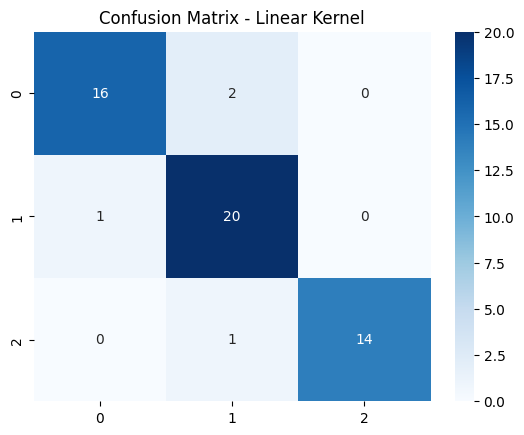

In [ ]:
##Visualize Confusion Matrix
model_linear = models['linear']

y_pred_linear = model_linear.predict(X_test)
cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure()
sns.heatmap(cm_linear, cmap='Blues', annot=True, fmt='d')
plt.title("Confusion Matrix - Linear Kernel")
plt.show()


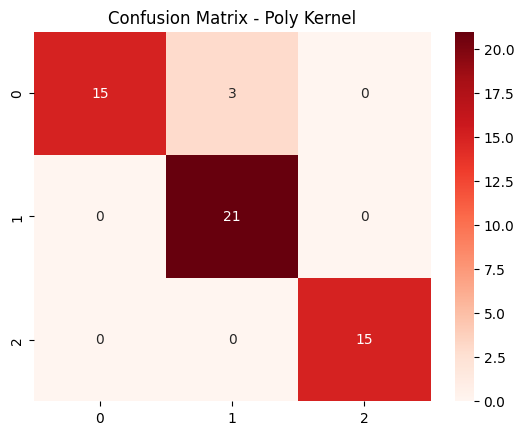

In [ ]:
model_poly = models['poly']

y_pred_poly = model_poly.predict(X_test)
cm_poly = confusion_matrix(y_test, y_pred_poly)

plt.figure()
sns.heatmap(cm_poly, cmap='Reds', annot=True, fmt='d')
plt.title("Confusion Matrix - Poly Kernel")
plt.show()

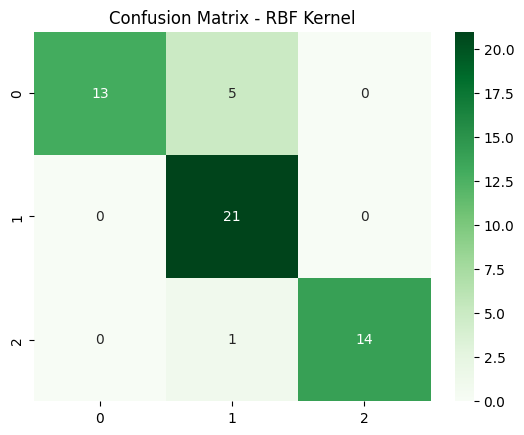

In [ ]:
model_RBF = models['rbf']

y_pred_RBF = model_RBF.predict(X_test)
cm_RBF = confusion_matrix(y_test, y_pred_RBF)

plt.figure()
sns.heatmap(cm_RBF, cmap='Greens', annot=True, fmt='d')
plt.title("Confusion Matrix - RBF Kernel")
plt.show()

# <font color="magenta"> **Visualize learned SVM model decision boundary**


# Problem-2: Implement a linear SVM classifier on Iris data set using first two featurs and two classes 0 and 1, and disply the learned classifier, decision function boundary, margin and support vectors.

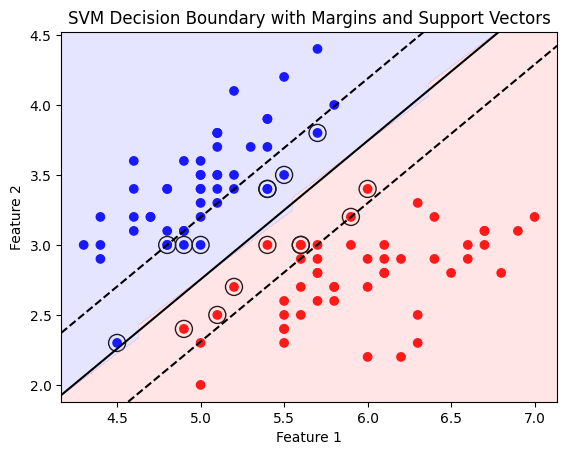

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load dataset (use only 2 features for 2D visualization)
iris = datasets.load_iris()
X = iris.data[:, :2]   # take first two features
y = iris.target

##Convert to binary problem (class 0 vs 1)
X = X[y != 2]
y = y[y != 2]

##Train SVM model
##===========================================
## ~~~ Write two lines of code here ~~~
model = SVC(kernel='linear')
model.fit(X, y)

##Plot data points
##===========================================
## ~~~ Write one line of code here ~~~
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

##Plot support vectors
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k')

# Create grid for decision regions
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k',
           levels=[-1, 0, 1],
           linestyles=['--', '-', '--'])

# Fill regions
ax.contourf(XX, YY, Z > 0, alpha=0.2, cmap='bwr')

plt.title("SVM Decision Boundary with Margins and Support Vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Problem-3: Implement a nonlinear SVM classifier on synthetic non-linear data set using RBF kernel, and disply the learned classifier, decision function boundary, margin and support vectors.

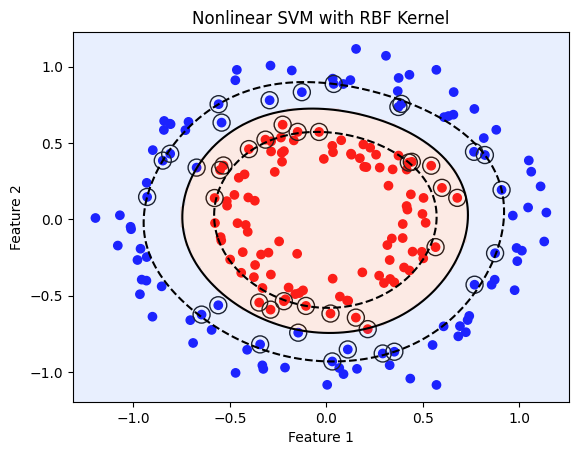

In [ ]:
##Import library functions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

##Generate 2D non-linear dataset using make_circles() function
X, y = make_circles(n_samples=200, factor=0.5, noise=0.1)

##Train SVM with RBF kernel
##===========================================
## ~~~ Write two lines of code here ~~~
model = SVC(kernel='rbf')
model.fit(X, y)

##Plot data points using scatter plot
##===========================================
## ~~~ Write one line of code here ~~~
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

##Plot support vectors on the same plot
##===========================================
## ~~~ Write one line of code here ~~~
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k')

##Create grid for decision regions
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)

YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

##Plot decision boundary and margins (curved)
ax.contour(XX, YY, Z, levels=[-1, 0, 1],
           linestyles=['--', '-', '--'], colors='k')

## Fill regions
ax.contourf(XX, YY, Z > 0, alpha=0.2, cmap='coolwarm')

plt.title("Nonlinear SVM with RBF Kernel")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Problem-3: Implement a nonlinear SVM classifier on synthetic 3-class spiral data set using RBF kernel, and disply the learned classifier, decision function boundary, margin and support vectors.

In [ ]:
##Step-1: Upload file
from google.colab import files
uploaded = files.upload()

Saving 3classSpiralData.txt to 3classSpiralData.txt


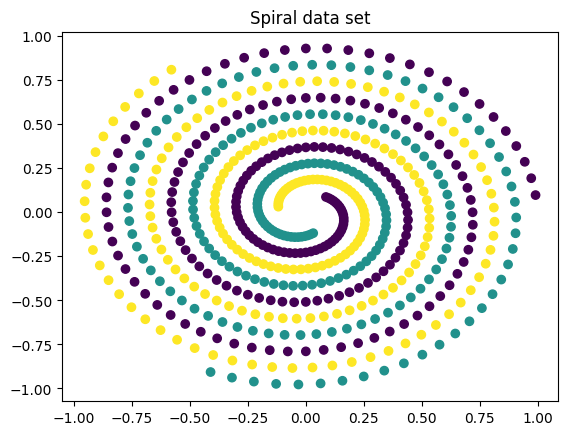

In [ ]:
##Step-2:Load the data set, separate data and Target,
## and display the data in 2D using scatter plot
data = np.loadtxt('3classSpiralData.txt', encoding='utf-8-sig')

##Separate data and target
X = data[:, :2]
y = data[:, 2]

##Display the data set
##===========================================
## ~~~ Write one line of code here ~~~
plt.scatter(X[:, 0], X[:, 1], c=y)

plt.title("Spiral data set")
plt.show()

In [ ]:
##Step-3: Train SVM classifier with RBF kernel
##===========================================
## ~~~ Write two lines of code here ~~~
model = SVC(kernel='rbf')
model.fit(X, y)

SVC()

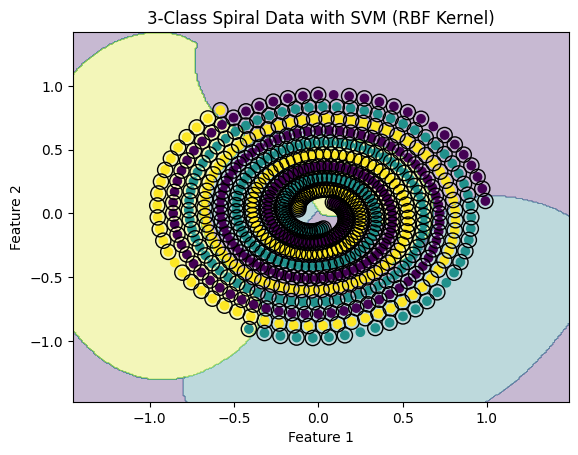

In [ ]:
##Step-4: Display the learned classifier
##Create mesh grid within the minimum and maximum values of the data set with step=0.01
h = 0.01
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

##Predict over grid
##===========================================
## ~~~ Write two lines of code here ~~~
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

###Plot regions
##===========================================
## ~~~ Write one line of code here ~~~
plt.contourf(xx, yy, Z, alpha=0.3)

##Plot data points
##===========================================
## ~~~ Write one line of code here ~~~
plt.scatter(X[:, 0], X[:, 1], c=y)

#Plot support vectors
##===========================================
## ~~~ Write one line of code here ~~~
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='k')

##Add titles and labels to the plot
plt.title("3-Class Spiral Data with SVM (RBF Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()